6.  Develop a Map Reduce program to calculate the maximum, minimum, and mean values of sepal length, sepal width, petal length, and petal width from the iris flower dataset. VIsualize the relationship between sepal length and sepal width and also between petal length and petal width.

In [18]:
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np

In [19]:
iris = load_iris()
data = iris.data  # Features
feature_names = iris.feature_names
attributes = ["sepal length", "sepal width", "petal length", "petal width"]

In [20]:
def mapper(data):
    results = defaultdict(list)
    for row in data:
        for i, value in enumerate(row):
            results[i].append(value)
    return results

def reducer(mapped_data):
    reduced_data = {}
    for key, values in mapped_data.items():
        reduced_data[attributes[key]] = {
            "max": max(values),
            "min": min(values),
            "mean": sum(values) / len(values),
        }
    return reduced_data

In [21]:
mapped_data = mapper(data)

reduced_data = reducer(mapped_data)

print("Summary Statistics:")
for attribute, stats in reduced_data.items():
    print(f"{attribute.capitalize()}: Max={stats['max']}, Min={stats['min']}, Mean={stats['mean']:.2f}")

Summary Statistics:
Sepal length: Max=7.9, Min=4.3, Mean=5.84
Sepal width: Max=4.4, Min=2.0, Mean=3.06
Petal length: Max=6.9, Min=1.0, Mean=3.76
Petal width: Max=2.5, Min=0.1, Mean=1.20


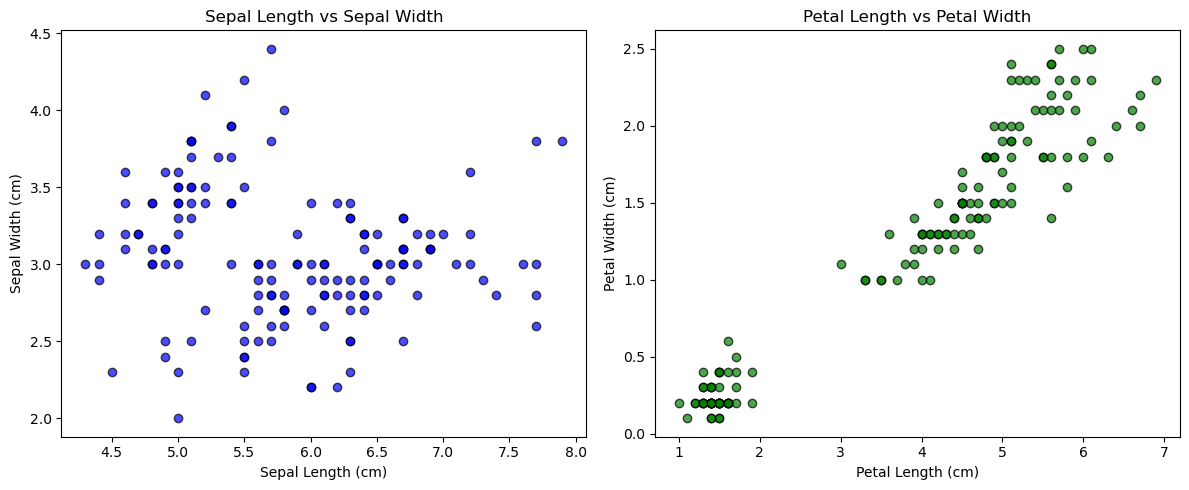

In [22]:
sepal_length = data[:, 0]  
sepal_width = data[:, 1]   
petal_length = data[:, 2]  
petal_width = data[:, 3]  

# Scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(sepal_length, sepal_width, c='blue', edgecolor='k', alpha=0.7)
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.subplot(1, 2, 2)
plt.scatter(petal_length, petal_width, c='green', edgecolor='k', alpha=0.7)
plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.tight_layout()
plt.show()